# Module 08: Expression Variability Analysis

## Overview
This module examines transcriptional variability in senescent vs non-senescent cells and contextualizes senescence effects relative to other biological factors.

## Biological Questions
1. **What is the transcriptional signature of senescent cells?** (DEG summary)
2. **Do SnC cells show higher transcriptional variability than Non-SnC cells?** (CV analysis)
3. **What factors explain variance in gene expression?** (Variance partitioning)

## Workflow
- **08A**: DEG Summary Visualization (Figure 3A)
- **08B**: Coefficient of Variation Analysis
- **08C**: Variance Partitioning (Figure 3B)
- **08D**: Integrated Figure

---

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-1: LIBRARIES
# ════════════════════════════════════════════════════════════════════════════════

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Publication-ready figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'pdf.fonttype': 42,
})
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)

print("✓ Libraries loaded")
print("✓ Figure settings configured")

# ════════════════════════════════════════════════════════════════════════════════
# 08A-2: COLOR CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

# Study_Group colors
STUDY_GROUP_COLORS = {
    # Aging cohorts
    'Age_20_29': '#2E86AB',
    'Age_30_39': '#4A90E2',
    'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347',
    'Age_60_69': '#FF8C00',
    'Age_70_79': '#E24A4A',
    'Age_80_100': '#8B0000',
    # Disease cohorts
    'Control': '#4E79A7',
    'MCI': '#F28E2B',
    'AD': '#E15759',
    'NCI': '#4E79A7',
}

# Senescence colors
SNC_COLORS = {"SnC": "#D73027", "Non-SnC": "#BDBDBD"}

# Cell type colors
CELL_TYPE_COLORS = {
    'Microglia': '#EDC948',
    'Astrocyte': '#E15759',
    'OPC': '#59A14F',
    'Oligodendrocyte': '#76B7B2',
    'Excitatory': '#4E79A7',
    'Inhibitory': '#F28E2B',
    'Endothelial': '#B07AA1',
}

# Sex colors
SEX_COLORS = {
    'Male': '#5D6D7E', 'Female': '#A569BD',
    'M': '#5D6D7E', 'F': '#A569BD',
}

print("✓ Color palettes configured")

# ════════════════════════════════════════════════════════════════════════════════
# 08A-3: DATASET CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = "psychad_aging"
CELL_TYPE = "Microglia"

STUDY_CONFIG = {
    'psychad_aging': {
        'type': 'aging',
        'primary_var': 'Age',
        'primary_var_type': 'continuous',
        'covariates': ['Sex', 'Cohort'],
        'random_effect': 'Sample',
        'sex_col': 'Sex',
        'cohort_col': 'Cohort',
        'cell_type_col': 'subclass',
        'sample_col': 'Sample',
        'senescence_col': 'senescence_label',
        'study_group_col': 'Study_Group',
        'group_order': ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 
                        'Age_60_69', 'Age_70_79', 'Age_80_100'],
    },
    'psychad_ad': {
        'type': 'disease',
        'primary_var': 'Study_Group',
        'primary_var_type': 'categorical',
        'reference_group': 'Control',
        'covariates': ['Age', 'Sex', 'Cohort'],
        'random_effect': 'Sample',
        'sex_col': 'Sex',
        'cohort_col': 'Cohort',
        'cell_type_col': 'subclass',
        'sample_col': 'Sample',
        'senescence_col': 'senescence_label',
        'study_group_col': 'Study_Group',
        'group_order': ['Control', 'MCI', 'AD'],
    },
    'psychencode': {
        'type': 'aging',
        'primary_var': 'Age_death',
        'primary_var_type': 'continuous',
        'covariates': ['Biological_Sex', 'Cohort'],
        'random_effect': 'sample_id',
        'sex_col': 'Biological_Sex',
        'cohort_col': 'Cohort',
        'cell_type_col': 'cell_type',
        'sample_col': 'sample_id',
        'senescence_col': 'senescence_label',
        'study_group_col': 'Study_Group',
        'group_order': ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 
                        'Age_60_69', 'Age_70_79', 'Age_80_100'],
    },
}

# Extract config
config = STUDY_CONFIG[DATASET]
STUDY_TYPE = config['type']
GROUP_ORDER = config['group_order']
CELL_TYPE_COL = config['cell_type_col']
SAMPLE_COL = config['sample_col']
SENESCENCE_COL = config['senescence_col']
STUDY_GROUP_COL = config['study_group_col']

# Paths
BASE_DIR = Path("/fs/scratch/PAS2598/senescence_analysis")
SC_FILE = BASE_DIR / "data" / "04_subclustered" / DATASET / f"{DATASET}_subclustered.h5ad"
DEG_RESULTS_DIR = BASE_DIR / "results" / "05_deg" / DATASET / CELL_TYPE.lower()
RESULTS_DIR = BASE_DIR / "results" / "08_variability" / DATASET / CELL_TYPE.lower()
FIGURES_DIR = BASE_DIR / "figures" / "08_variability" / DATASET / CELL_TYPE.lower()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Thresholds
FDR_THRESHOLD = 0.05
LFC_THRESHOLD = 0.5

print("=" * 80)
print(f"Dataset: {DATASET}")
print(f"Cell type: {CELL_TYPE}")
print(f"Study type: {STUDY_TYPE}")
print(f"Group order: {GROUP_ORDER}")
print(f"SC file: {SC_FILE.name}")
print(f"DEG results: {DEG_RESULTS_DIR}")
print("=" * 80)

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


✓ Libraries loaded
✓ Figure settings configured
✓ Color palettes configured
Dataset: psychad_aging
Cell type: Microglia
Study type: aging
Group order: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
SC file: psychad_aging_subclustered.h5ad
DEG results: /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/microglia


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-2: CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = "psychad_aging"
CELL_TYPE = "Microglia"
BASE_DIR = Path("/fs/scratch/PAS2598/senescence_analysis")

# Input paths
SC_FILE = BASE_DIR / "data" / "04_subclustered" / DATASET / f"{DATASET}_subclustered.h5ad"
DEG_RESULTS_DIR = BASE_DIR / "results" / "05_deg" / DATASET / CELL_TYPE.lower()

# Output paths
RESULTS_DIR = BASE_DIR / "results" / "08_variability" / DATASET / CELL_TYPE.lower()
FIGURES_DIR = BASE_DIR / "figures" / "08_variability" / DATASET / CELL_TYPE.lower()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Thresholds
FDR_THRESHOLD = 0.05
LFC_THRESHOLD = 2

# Column mappings
CELL_TYPE_COL = "subclass"
SENESCENCE_COL = "senescence_label"
SAMPLE_COL = "Sample"
STUDY_GROUP_COL = "Study_Group"

print(f"Configuration:")
print(f"  Dataset: {DATASET}")
print(f"  Cell type: {CELL_TYPE}")
print(f"  SC file: {SC_FILE.name}")
print(f"  DEG results: {DEG_RESULTS_DIR}")

Configuration:
  Dataset: psychad_aging
  Cell type: Microglia
  SC file: psychad_aging_subclustered.h5ad
  DEG results: /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/microglia


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-3: LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

# Load single-cell data
print("Loading single-cell data...")
adata_all = sc.read_h5ad(SC_FILE)
print(f"  Total cells: {adata_all.n_obs:,}")

# Subset to cell type
adata = adata_all[adata_all.obs[CELL_TYPE_COL] == CELL_TYPE].copy()
print(f"  {CELL_TYPE} cells: {adata.n_obs:,}")

# Check senescence distribution
print(f"\nSenescence distribution:")
print(adata.obs[SENESCENCE_COL].value_counts())

# Clean up
del adata_all

print("\n✓ Data loaded")

Loading single-cell data...
  Total cells: 122,192
  Microglia cells: 22,475

Senescence distribution:
senescence_label
Non-SnC    20242
SnC         2233
Name: count, dtype: int64

✓ Data loaded


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-4: LOAD DEG RESULTS
# ════════════════════════════════════════════════════════════════════════════════

# List available comparisons
deg_files = list(DEG_RESULTS_DIR.glob("*.csv"))
deg_files = [f for f in deg_files if not any(x in f.name for x in ["summary", "gsea", "genes", "pseudobulk"])]

print("Available comparisons:")
for f in deg_files:
    print(f"  • {f.name}")

# Select comparison
COMPARISON = "SnCvsNonSnC_all"
deg_file = DEG_RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{COMPARISON}.csv"

deg_data = pd.read_csv(deg_file)
print(f"\n--- Loaded: {COMPARISON} ---")
print(f"Total genes tested: {len(deg_data):,}")

# Ensure direction column
if "direction" not in deg_data.columns:
    deg_data["significant"] = (deg_data["p_val_adj"] < FDR_THRESHOLD) & (deg_data["avg_log2FC"].abs() > LFC_THRESHOLD)
    deg_data["direction"] = "NS"
    deg_data.loc[deg_data["significant"] & (deg_data["avg_log2FC"] > 2), "direction"] = "Up"
    deg_data.loc[deg_data["significant"] & (deg_data["avg_log2FC"] < 2), "direction"] = "Down"

# Summary
n_up = (deg_data["direction"] == "Up").sum()
n_down = (deg_data["direction"] == "Down").sum()
n_total = n_up + n_down

print(f"\nDEG Summary:")
print(f"  Up: {n_up}")
print(f"  Down: {n_down}")
print(f"  Total: {n_total}")

Available comparisons:
  • psychad_aging_microglia_OldvsYoung_SnC.csv
  • psychad_aging_microglia_OldvsYoung_all.csv
  • psychad_aging_microglia_SnCvsNonSnC_Young.csv
  • psychad_aging_microglia_SnCvsNonSnC_all.csv
  • psychad_aging_microglia_SnCvsNonSnC_Old.csv
  • psychad_aging_microglia_OldvsYoung_NonSnC.csv

--- Loaded: SnCvsNonSnC_all ---
Total genes tested: 33,557

DEG Summary:
  Up: 74
  Down: 54
  Total: 128


In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-5: SUMMARY TABLES
# ════════════════════════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────────────────────
# DEG Summary
# ────────────────────────────────────────────────────────────────────────────────
deg_summary = pd.DataFrame({
    "cell_type": [CELL_TYPE],
    "comparison": [COMPARISON],
    "genes_tested": [len(deg_data)],
    "up": [n_up],
    "down": [n_down],
    "total_deg": [n_total],
    "pct_up": [round(100 * n_up / n_total, 1)],
    "pct_down": [round(100 * n_down / n_total, 1)]
})

print("--- DEG Summary ---")
print(deg_summary.to_string(index=False))

# ────────────────────────────────────────────────────────────────────────────────
# Donor-level Transcriptional Activity (FIXED)
# ────────────────────────────────────────────────────────────────────────────────

# Step 1: Compute stats per donor-senescence (without Study_Group in groupby)
donor_stats = adata.obs.groupby([SAMPLE_COL, SENESCENCE_COL], observed=True).agg(
    n_cells=("n_genes", "size"),
    median_UMI=("total_counts", "median"),
    median_genes=("n_genes", "median")
).reset_index()
donor_stats = donor_stats.rename(columns={SAMPLE_COL: "Sample", SENESCENCE_COL: "Senescence"})

# Step 2: Get donor-level Study_Group (one per donor)
donor_sg = adata.obs.groupby(SAMPLE_COL, observed=True)[STUDY_GROUP_COL].first().reset_index()
donor_sg.columns = ["Sample", "Study_Group"]

# Step 3: Merge
donor_stats = donor_stats.merge(donor_sg, on="Sample", how="left")

print(f"\n--- Donor-level Summary ---")
print(f"Unique donors: {donor_stats['Sample'].nunique()}")
print(f"Rows in donor_stats: {len(donor_stats)} (should be ~2x donors for SnC/Non-SnC)")

print(f"\n--- Donors per Study_Group ---")
print(donor_sg["Study_Group"].value_counts().sort_index())

print(f"\n--- Overall Summary ---")
donor_overall = donor_stats.groupby("Senescence", observed=True).agg(
    n_donors=("Sample", "nunique"),
    median_UMI=("median_UMI", "median"),
    median_genes=("median_genes", "median")
)
print(donor_overall)

print(f"\n--- Summary by Study_Group ---")
donor_by_group = donor_stats.groupby(["Study_Group", "Senescence"], observed=True).agg(
    n_donors=("Sample", "nunique"),
    median_UMI=("median_UMI", "median"),
    median_genes=("median_genes", "median")
)
print(donor_by_group)

--- DEG Summary ---
cell_type      comparison  genes_tested  up  down  total_deg  pct_up  pct_down
Microglia SnCvsNonSnC_all         33557  74    54        128    57.8      42.2

--- Donor-level Summary ---
Unique donors: 124
Rows in donor_stats: 227 (should be ~2x donors for SnC/Non-SnC)

--- Donors per Study_Group ---
Study_Group
Age_20_29     16
Age_30_39     14
Age_40_49     18
Age_50_59     18
Age_60_69     20
Age_70_79     22
Age_80_100    16
Name: count, dtype: int64

--- Overall Summary ---
            n_donors  median_UMI  median_genes
Senescence                                    
Non-SnC          124      3451.0        2046.0
SnC              103      7654.0        3344.0

--- Summary by Study_Group ---
                        n_donors  median_UMI  median_genes
Study_Group Senescence                                    
Age_20_29   Non-SnC           16     3078.00       1831.75
            SnC               11     7101.00       3176.00
Age_30_39   Non-SnC           14     301

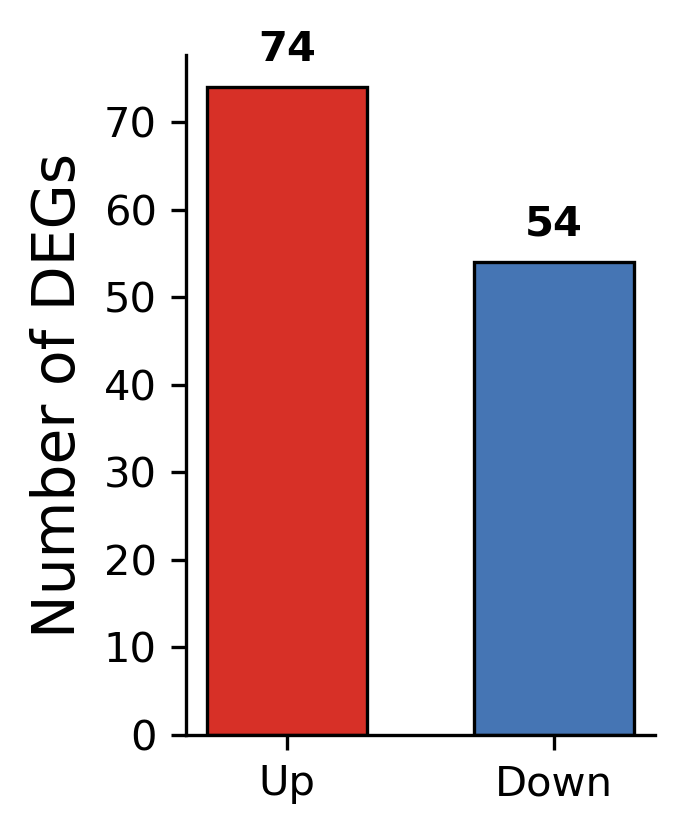

✓ Saved: psychad_aging_microglia_deg_barplot.pdf
  Up: 74 | Down: 54 | Total: 128


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-8: DEG BAR PLOT (Up vs Down)
# ════════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(2.5, 3))

# Data
categories = ["Up", "Down"]
counts = [n_up, n_down]
colors = ["#D73027", "#4575B4"]

# Bar plot
bars = ax.bar(categories, counts, color=colors, edgecolor="black", linewidth=0.8, width=0.6)

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            str(count), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Number of DEGs")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_deg_barplot.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Saved: {DATASET}_{CELL_TYPE.lower()}_deg_barplot.pdf")
print(f"  Up: {n_up} | Down: {n_down} | Total: {n_up + n_down}")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


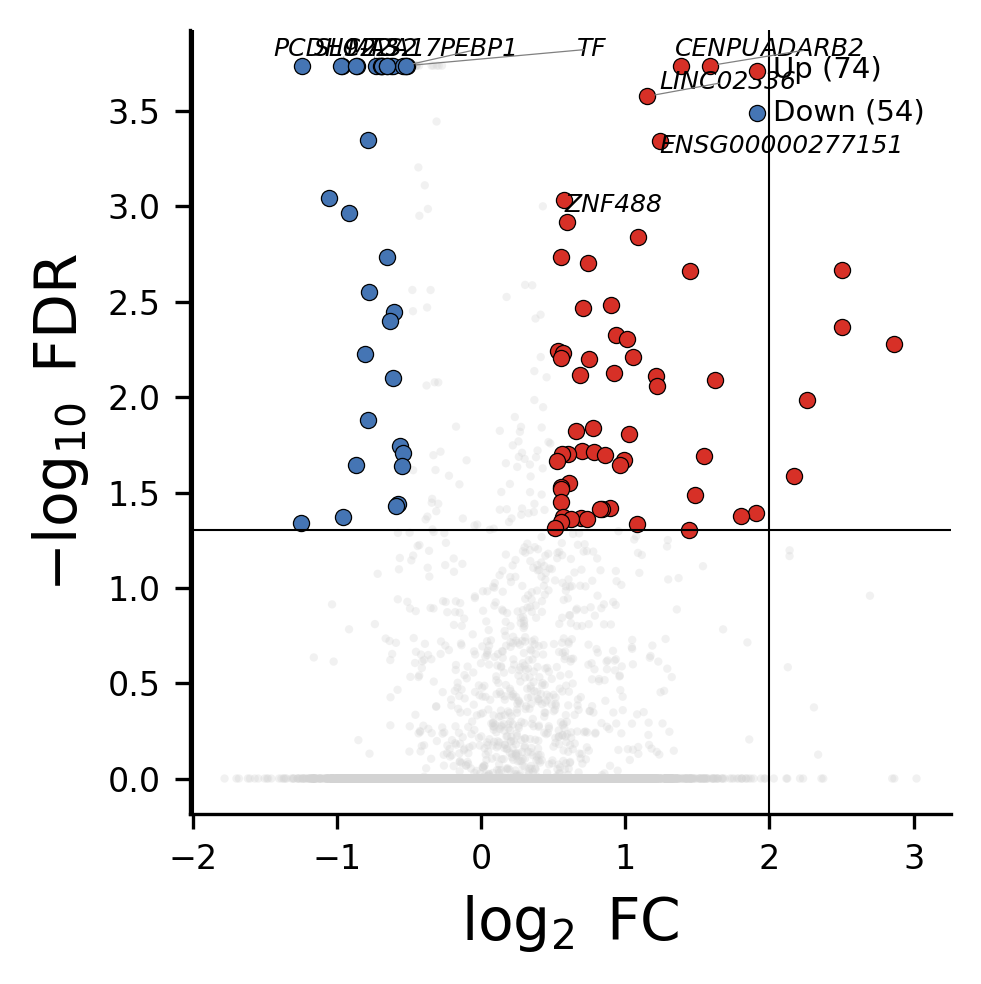

✓ Saved: psychad_aging_microglia_volcano.pdf


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-6: VOLCANO PLOT
# ════════════════════════════════════════════════════════════════════════════════

try:
    from adjustText import adjust_text
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "adjustText", "-q"])
    from adjustText import adjust_text

# Prepare data
deg_plot = deg_data.copy()
deg_plot["neg_log10_pval"] = -np.log10(deg_plot["p_val_adj"])

# Cap extreme values
max_p = np.nanquantile(deg_plot["neg_log10_pval"][np.isfinite(deg_plot["neg_log10_pval"])], 0.999)
deg_plot["neg_log10_pval"] = deg_plot["neg_log10_pval"].clip(upper=max_p)
deg_plot["neg_log10_pval"] = deg_plot["neg_log10_pval"].replace([np.inf, -np.inf], max_p)

# Top genes to label
top_up = deg_plot[deg_plot["direction"] == "Up"].nsmallest(5, "p_val_adj")["gene"].tolist()
top_down = deg_plot[deg_plot["direction"] == "Down"].nsmallest(5, "p_val_adj")["gene"].tolist()
top_genes = top_up + top_down

# Plot
fig, ax = plt.subplots(figsize=(3.5, 3.5))

# NS points
ns_data = deg_plot[deg_plot["direction"] == "NS"]
ax.scatter(ns_data["avg_log2FC"], ns_data["neg_log10_pval"], 
           c="#D3D3D3", s=4, alpha=0.3, edgecolors="none", rasterized=True)

# Significant points
for direction, color in [("Up", "#D73027"), ("Down", "#4575B4")]:
    data = deg_plot[deg_plot["direction"] == direction]
    ax.scatter(data["avg_log2FC"], data["neg_log10_pval"],
               c=color, s=15, edgecolors="black", linewidths=0.3, 
               label=f"{direction} ({len(data)})")

# Threshold lines
ax.axhline(-np.log10(FDR_THRESHOLD), color="black", linewidth=0.5)
ax.axvline(-LFC_THRESHOLD, color="black", linewidth=0.5)
ax.axvline(LFC_THRESHOLD, color="black", linewidth=0.5)

# Labels
texts = []
label_data = deg_plot[deg_plot["gene"].isin(top_genes)]
for _, row in label_data.iterrows():
    texts.append(ax.text(row["avg_log2FC"], row["neg_log10_pval"], row["gene"],
                         fontsize=6, fontstyle="italic"))

adjust_text(texts, ax=ax,
            x=label_data["avg_log2FC"].values,
            y=label_data["neg_log10_pval"].values,
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.3),
            expand_points=(2, 2), force_points=(1, 1), force_text=(1, 1))

# Aesthetics - no grid
ax.set_xlabel(r"$\log_2$ FC")
ax.set_ylabel(r"$-\log_{10}$ FDR")
ax.legend(loc="upper right", frameon=False, fontsize=7, handletextpad=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.set_facecolor("white")
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_volcano.pdf", bbox_inches="tight")
plt.show()

print(f"✓ Saved: {DATASET}_{CELL_TYPE.lower()}_volcano.pdf")

/tmp/ipykernel_558642/3181393404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=donor_stats, x="Senescence", y="median_UMI",


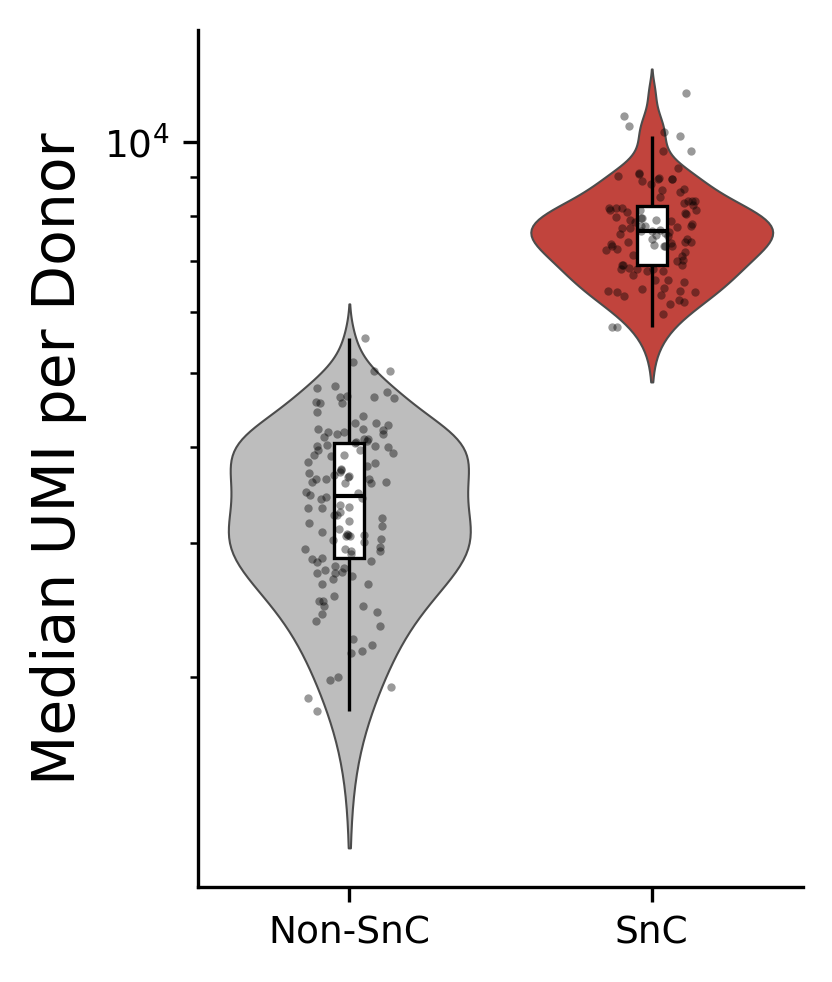

✓ Saved: psychad_aging_microglia_violin_umi.pdf


In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-7: VIOLIN PLOT (Donor-level)
# ════════════════════════════════════════════════════════════════════════════════

# Colors
SNC_COLORS = {"SnC": "#D73027", "Non-SnC": "#BDBDBD"}

# Plot
fig, ax = plt.subplots(figsize=(3, 3.5))

sns.violinplot(data=donor_stats, x="Senescence", y="median_UMI", 
               order=["Non-SnC", "SnC"], palette=SNC_COLORS,
               inner=None, linewidth=0.5, ax=ax)

sns.stripplot(data=donor_stats, x="Senescence", y="median_UMI",
              order=["Non-SnC", "SnC"], color="black", size=2, alpha=0.4, 
              jitter=0.15, ax=ax)

sns.boxplot(data=donor_stats, x="Senescence", y="median_UMI",
            order=["Non-SnC", "SnC"], width=0.1, showcaps=False,
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=0.8),
            whiskerprops=dict(color="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1),
            fliersize=0, ax=ax)

ax.set_yscale("log")
ax.set_xlabel("")
ax.set_ylabel("Median UMI per Donor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_violin_umi.pdf", bbox_inches="tight")
plt.show()

print(f"✓ Saved: {DATASET}_{CELL_TYPE.lower()}_violin_umi.pdf")

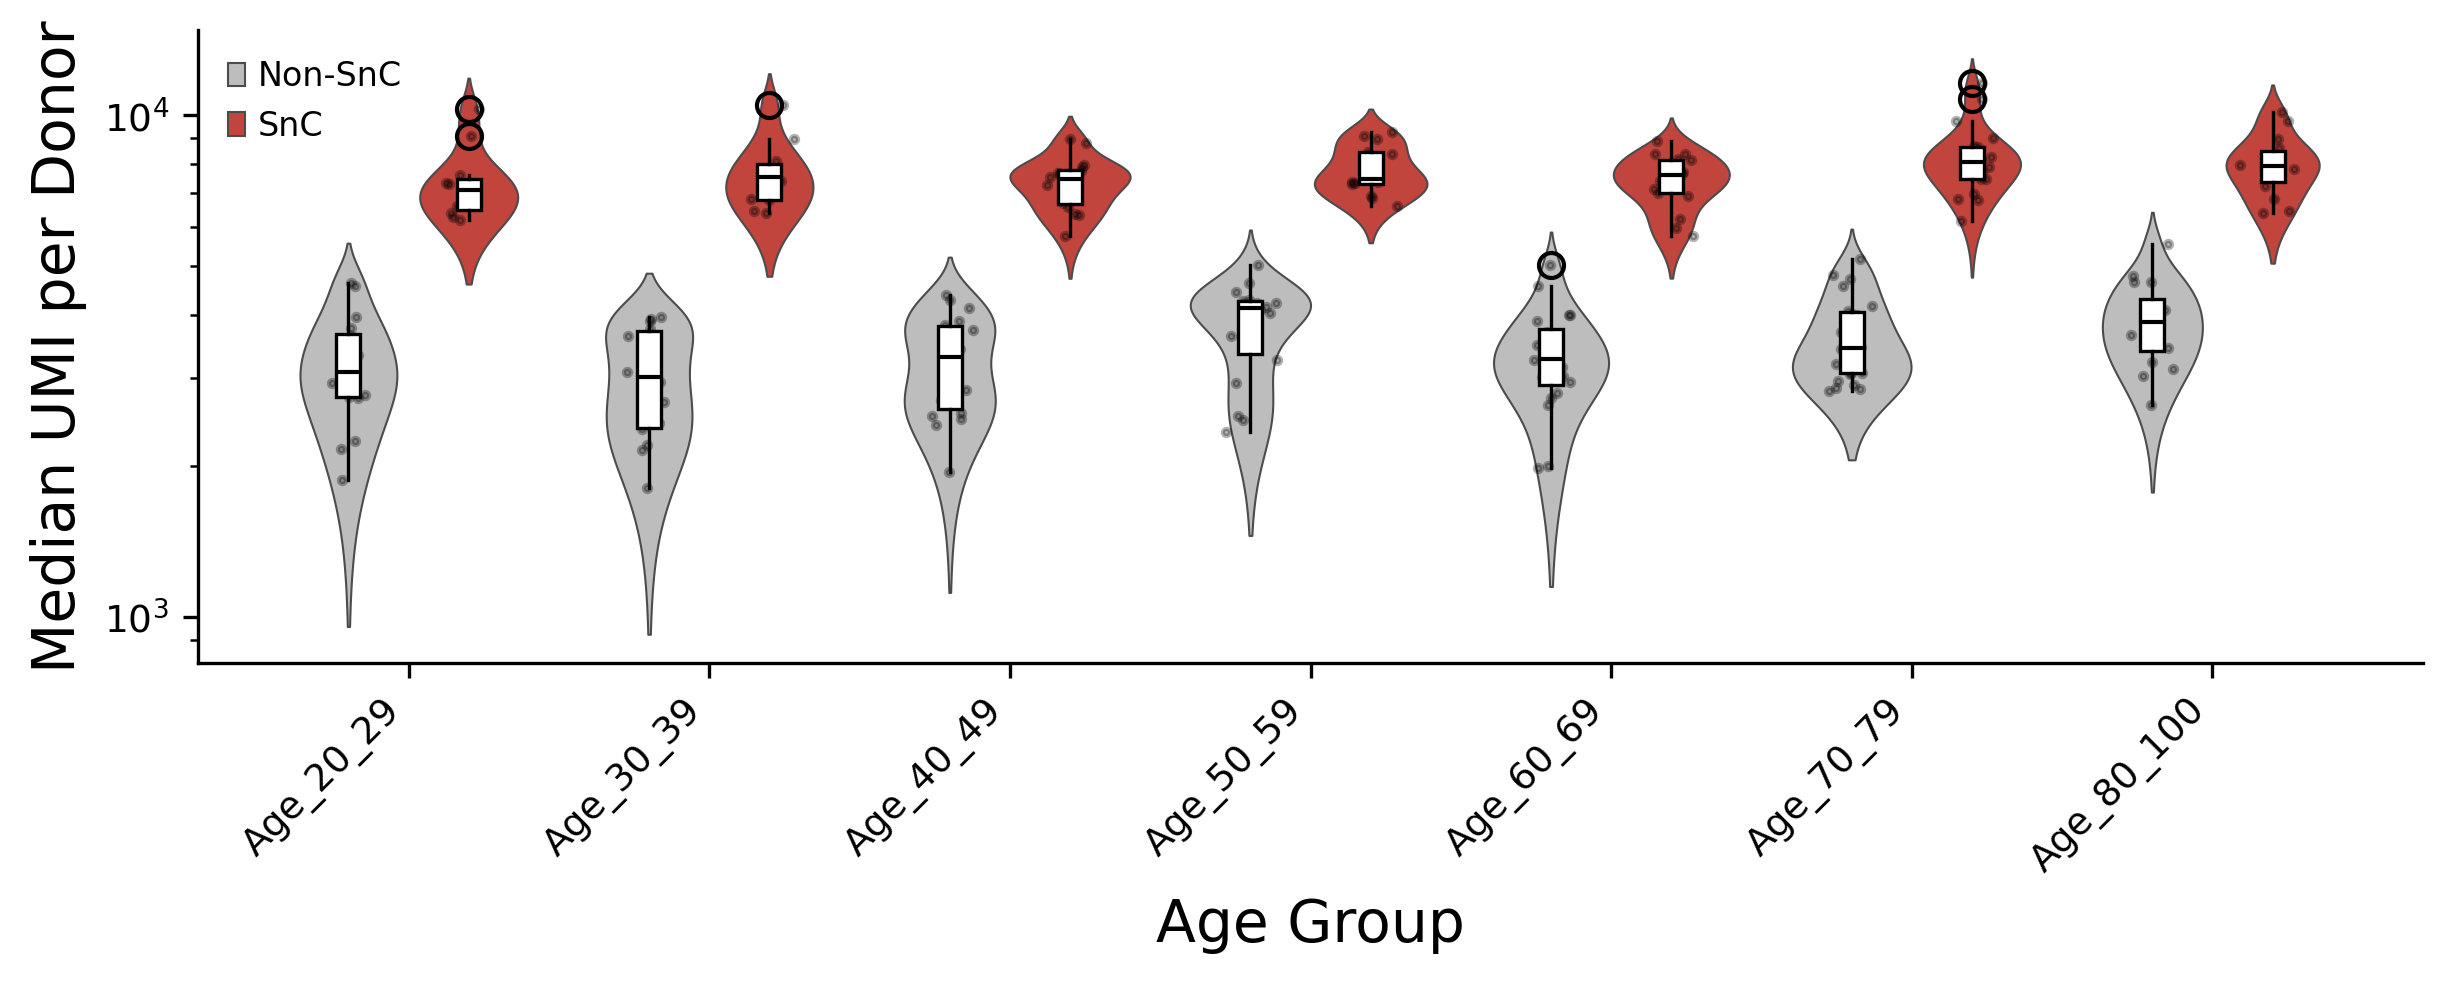

✓ Saved: psychad_aging_microglia_violin_umi_by_studygroup_snc.pdf


In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-7b: VIOLIN PLOT (Donor-level by Study Group, split by Senescence)
# ════════════════════════════════════════════════════════════════════════════════

# Get study groups in order
study_groups = [g for g in GROUP_ORDER if g in donor_stats["Study_Group"].values]
n_groups = len(study_groups)

# Plot
fig, ax = plt.subplots(figsize=(max(4, n_groups * 1.2), 3.5))

violin = sns.violinplot(data=donor_stats, x="Study_Group", y="median_UMI",
                        hue="Senescence", hue_order=["Non-SnC", "SnC"],
                        order=study_groups, palette=SNC_COLORS,
                        inner=None, linewidth=0.5, dodge=True, ax=ax)

# Get violin positions for alignment
dodge_width = 0.4
positions = []
for i in range(n_groups):
    positions.extend([i - dodge_width/2, i + dodge_width/2])

# Stripplot and boxplot aligned to violin centers
for j, snc_status in enumerate(["Non-SnC", "SnC"]):
    subset = donor_stats[donor_stats["Senescence"] == snc_status]
    pos = [i + (j - 0.5) * dodge_width for i in range(n_groups)]
    
    for i, grp in enumerate(study_groups):
        grp_data = subset[subset["Study_Group"] == grp]["median_UMI"].dropna()
        if len(grp_data) > 0:
            # Jittered points
            ax.scatter(np.random.normal(pos[i], 0.04, len(grp_data)), grp_data,
                       color="black", s=3, alpha=0.3, zorder=3)
            # Boxplot
            bp = ax.boxplot(grp_data, positions=[pos[i]], widths=0.08, 
                            showcaps=False, patch_artist=True, zorder=4)
            bp['boxes'][0].set(facecolor='white', edgecolor='black', linewidth=0.8)
            bp['whiskers'][0].set(color='black', linewidth=0.8)
            bp['whiskers'][1].set(color='black', linewidth=0.8)
            bp['medians'][0].set(color='black', linewidth=1)

ax.set_yscale("log")
ax.set_xlabel("Age Group" if STUDY_TYPE == "aging" else "Study Group")
ax.set_ylabel("Median UMI per Donor")
ax.set_xticks(range(n_groups))
ax.set_xticklabels(study_groups, rotation=45, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="both", labelsize=9)

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], loc="upper left", frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_violin_umi_by_studygroup_snc.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Saved: {DATASET}_{CELL_TYPE.lower()}_violin_umi_by_studygroup_snc.pdf")

In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-9: SAVE RESULTS
# ════════════════════════════════════════════════════════════════════════════════

# Save DEG summary
deg_summary.to_csv(RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_deg_summary.csv", index=False)

# Save donor stats
donor_stats.to_csv(RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_donor_stats.csv", index=False)

print("--- Saved ---")
print(f"  • {DATASET}_{CELL_TYPE.lower()}_deg_summary.csv")
print(f"  • {DATASET}_{CELL_TYPE.lower()}_donor_stats.csv")
print(f"  • {DATASET}_{CELL_TYPE.lower()}_fig3ab.pdf")

print("\n--- 08A Complete ---")
print(f"  DEGs: {n_total} ({n_up} up, {n_down} down)")
print(f"  Median UMI - Non-SnC: {donor_stats[donor_stats['Senescence']=='Non-SnC']['median_UMI'].median():.0f}")
print(f"  Median UMI - SnC: {donor_stats[donor_stats['Senescence']=='SnC']['median_UMI'].median():.0f}")

--- Saved ---
  • psychad_aging_microglia_deg_summary.csv
  • psychad_aging_microglia_donor_stats.csv
  • psychad_aging_microglia_fig3ab.pdf

--- 08A Complete ---
  DEGs: 128 (74 up, 54 down)
  Median UMI - Non-SnC: 3451
  Median UMI - SnC: 7654


---

## 08B: Coefficient of Variation Analysis

**Question**: Do senescent cells show higher transcriptional variability (noise)?

**Method**: CV = σ/μ for each gene, compared between SnC and Non-SnC

---

In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B: COEFFICIENT OF VARIATION ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
# Question: Do senescent cells show higher transcriptional variability (noise)?
# Method: CV = σ/μ for each gene, compared between SnC and Non-SnC
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("08B: Coefficient of Variation Analysis")
print("=" * 80)

# ════════════════════════════════════════════════════════════════════════════════
# 08B-1: COMPUTE CV PER GENE
# ════════════════════════════════════════════════════════════════════════════════

from scipy import sparse

def compute_cv(adata, group_col, group_value, min_cells=50, min_mean=0.01):
    """Compute CV for each gene in a cell subset."""
    
    # Subset cells
    mask = adata.obs[group_col] == group_value
    subset = adata[mask]
    
    if subset.n_obs < min_cells:
        print(f"  Warning: {group_value} has only {subset.n_obs} cells")
        return None
    
    # Get expression matrix (use raw counts if available)
    if adata.raw is not None:
        X = adata.raw[mask].X
    else:
        X = subset.X
    
    # Convert to array if sparse
    if sparse.issparse(X):
        X = X.toarray()
    
    # Compute mean and std per gene
    means = np.mean(X, axis=0).flatten()
    stds = np.std(X, axis=0).flatten()
    
    # Compute CV (avoid division by zero)
    cv = np.divide(stds, means, out=np.zeros_like(stds), where=means > min_mean)
    
    # Get gene names
    if adata.raw is not None:
        genes = adata.raw.var_names
    else:
        genes = adata.var_names
    
    # Create dataframe
    cv_df = pd.DataFrame({
        "gene": genes,
        "mean": means,
        "std": stds,
        "cv": cv
    })
    
    # Filter low-expressed genes
    cv_df = cv_df[cv_df["mean"] > min_mean].copy()
    cv_df["group"] = group_value
    
    print(f"  {group_value}: {mask.sum():,} cells, {len(cv_df):,} genes (mean > {min_mean})")
    
    return cv_df

# Compute CV for SnC and Non-SnC
print("Computing CV per gene...")
cv_snc = compute_cv(adata, SENESCENCE_COL, "SnC")
cv_nonsnc = compute_cv(adata, SENESCENCE_COL, "Non-SnC")

# Merge
cv_data = pd.merge(
    cv_nonsnc[["gene", "mean", "cv"]].rename(columns={"mean": "mean_NonSnC", "cv": "cv_NonSnC"}),
    cv_snc[["gene", "mean", "cv"]].rename(columns={"mean": "mean_SnC", "cv": "cv_SnC"}),
    on="gene"
)

# Compute difference
cv_data["cv_diff"] = cv_data["cv_SnC"] - cv_data["cv_NonSnC"]
cv_data["cv_ratio"] = cv_data["cv_SnC"] / cv_data["cv_NonSnC"]

print(f"\n✓ CV computed for {len(cv_data):,} genes")
print(f"  Median CV (Non-SnC): {cv_data['cv_NonSnC'].median():.3f}")
print(f"  Median CV (SnC): {cv_data['cv_SnC'].median():.3f}")
print(f"  Median CV difference: {cv_data['cv_diff'].median():.3f}")

08B: Coefficient of Variation Analysis
Computing CV per gene...
  SnC: 2,233 cells, 18,900 genes (mean > 0.01)
  Non-SnC: 20,242 cells, 15,923 genes (mean > 0.01)

✓ CV computed for 15,905 genes
  Median CV (Non-SnC): 4.237
  Median CV (SnC): 3.050
  Median CV difference: -1.109


Wilcoxon signed-rank test: p = 0.00e+00


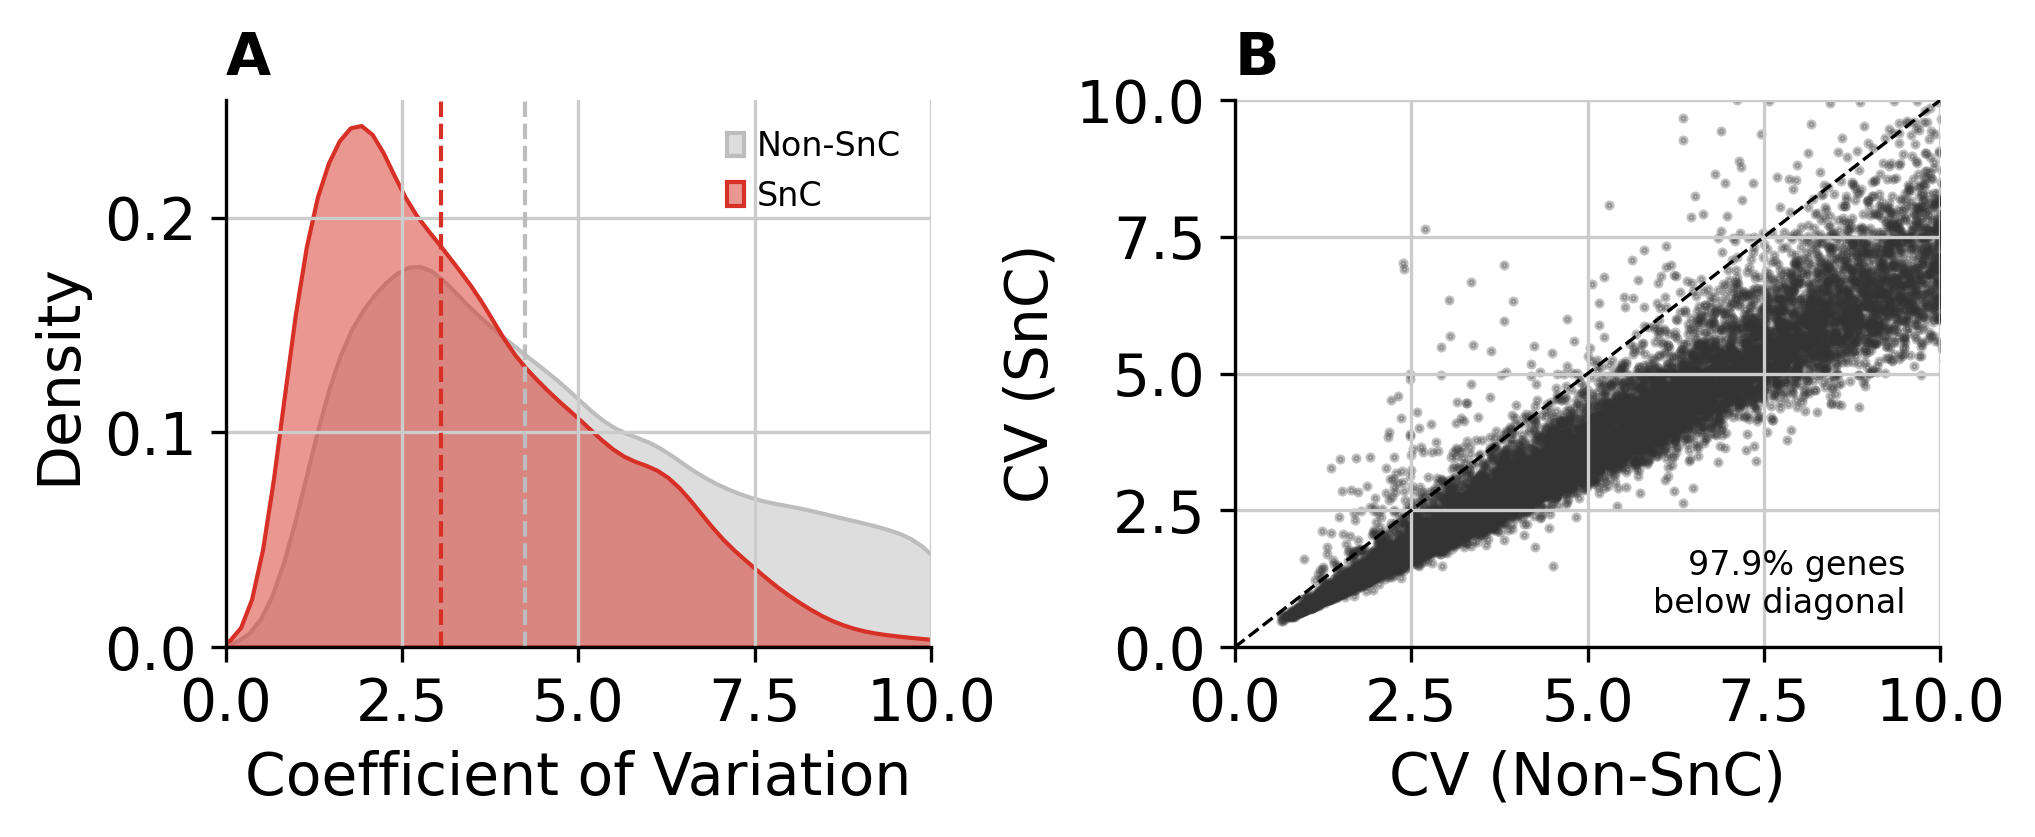


✓ Saved: psychad_aging_microglia_cv_analysis.pdf
  Genes with lower CV in SnC: 15,566 (97.9%)


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-2: CV VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon

# Statistical test (paired by gene)
stat, pval = wilcoxon(cv_data["cv_SnC"], cv_data["cv_NonSnC"])
print(f"Wilcoxon signed-rank test: p = {pval:.2e}")

# ────────────────────────────────────────────────────────────────────────────────
# Panel A: Density plot
# ────────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

ax = axes[0]
sns.kdeplot(data=cv_data, x="cv_NonSnC", fill=True, color=SNC_COLORS["Non-SnC"], 
            alpha=0.5, label="Non-SnC", ax=ax)
sns.kdeplot(data=cv_data, x="cv_SnC", fill=True, color=SNC_COLORS["SnC"], 
            alpha=0.5, label="SnC", ax=ax)
ax.axvline(cv_data["cv_NonSnC"].median(), color=SNC_COLORS["Non-SnC"], linestyle="--", linewidth=1)
ax.axvline(cv_data["cv_SnC"].median(), color=SNC_COLORS["SnC"], linestyle="--", linewidth=1)
ax.set_xlabel("Coefficient of Variation")
ax.set_ylabel("Density")
ax.set_xlim(0, 10)
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("A", loc="left", fontweight="bold")

# ────────────────────────────────────────────────────────────────────────────────
# Panel B: Scatter plot (CV_SnC vs CV_NonSnC)
# ────────────────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(cv_data["cv_NonSnC"], cv_data["cv_SnC"], s=2, alpha=0.3, c="#333333", rasterized=True)
ax.plot([0, 10], [0, 10], "k--", linewidth=0.8, label="y = x")
ax.set_xlabel("CV (Non-SnC)")
ax.set_ylabel("CV (SnC)")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("B", loc="left", fontweight="bold")

# Annotation
n_below = (cv_data["cv_SnC"] < cv_data["cv_NonSnC"]).sum()
pct_below = 100 * n_below / len(cv_data)
ax.text(0.95, 0.05, f"{pct_below:.1f}% genes\nbelow diagonal", 
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_cv_analysis.pdf", bbox_inches="tight")
plt.show()

print(f"\n✓ Saved: {DATASET}_{CELL_TYPE.lower()}_cv_analysis.pdf")
print(f"  Genes with lower CV in SnC: {n_below:,} ({pct_below:.1f}%)")

In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-4: DONOR-LEVEL CV ANALYSIS (Re-run with corrected donor_stats)
# ════════════════════════════════════════════════════════════════════════════════

from scipy import sparse
from scipy.stats import wilcoxon, mannwhitneyu, spearmanr
from sklearn.linear_model import LinearRegression

def compute_donor_cv(adata, sample_col, senescence_col, min_cells=10):
    """Compute mean CV per donor (across genes)."""
    
    results = []
    
    for (donor, snc_status), group in adata.obs.groupby([sample_col, senescence_col], observed=True):
        if len(group) < min_cells:
            continue
        
        # Get expression matrix
        idx = group.index
        if adata.raw is not None:
            X = adata.raw[idx].X
        else:
            X = adata[idx].X
        
        if sparse.issparse(X):
            X = X.toarray()
        
        # Compute CV per gene, then take median across genes
        means = np.mean(X, axis=0).flatten()
        stds = np.std(X, axis=0).flatten()
        
        # Filter expressed genes
        mask = means > 0.01
        if mask.sum() < 100:
            continue
            
        cvs = stds[mask] / means[mask]
        
        results.append({
            "donor": donor,
            "Senescence": snc_status,
            "n_cells": len(group),
            "n_genes": mask.sum(),
            "mean_cv": np.mean(cvs),
            "median_cv": np.median(cvs)
        })
    
    return pd.DataFrame(results)

print("Computing donor-level CV (min 10 cells per donor-senescence group)...")
donor_cv = compute_donor_cv(adata, SAMPLE_COL, SENESCENCE_COL, min_cells=10)

# Add Study_Group
donor_sg = adata.obs.groupby(SAMPLE_COL, observed=True)[STUDY_GROUP_COL].first().reset_index()
donor_sg.columns = ["donor", "Study_Group"]
donor_cv = donor_cv.merge(donor_sg, on="donor", how="left")

print(f"\n✓ Donors with sufficient SnC cells: {(donor_cv['Senescence'] == 'SnC').sum()}")
print(f"✓ Donors with sufficient Non-SnC cells: {(donor_cv['Senescence'] == 'Non-SnC').sum()}")

# Paired donors
donors_snc = set(donor_cv[donor_cv["Senescence"] == "SnC"]["donor"])
donors_nonsnc = set(donor_cv[donor_cv["Senescence"] == "Non-SnC"]["donor"])
paired_donors = donors_snc & donors_nonsnc
print(f"✓ Donors with BOTH (paired): {len(paired_donors)}")

# Summary by senescence
print("\n--- Donor-level CV Summary ---")
for snc in ["Non-SnC", "SnC"]:
    subset = donor_cv[donor_cv["Senescence"] == snc]
    print(f"  {snc}: n={len(subset)}, median CV={subset['median_cv'].median():.3f}")

# Summary by Study_Group
print("\n--- Donors per Study_Group (with sufficient cells) ---")
print(donor_cv.groupby(["Study_Group", "Senescence"], observed=True).size().unstack(fill_value=0))

Computing donor-level CV (min 10 cells per donor-senescence group)...

✓ Donors with sufficient SnC cells: 60
✓ Donors with sufficient Non-SnC cells: 117
✓ Donors with BOTH (paired): 60

--- Donor-level CV Summary ---
  Non-SnC: n=117, median CV=3.980
  SnC: n=60, median CV=2.770

--- Donors per Study_Group (with sufficient cells) ---
Senescence   Non-SnC  SnC
Study_Group              
Age_20_29         15    6
Age_30_39         13    5
Age_40_49         17    9
Age_50_59         17    9
Age_60_69         19    9
Age_70_79         21   10
Age_80_100        15   12


In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-4b: PAIRED DONOR-LEVEL CV ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon

# Check which donors have both SnC and Non-SnC
donors_snc = set(donor_cv[donor_cv["Senescence"] == "SnC"]["donor"])
donors_nonsnc = set(donor_cv[donor_cv["Senescence"] == "Non-SnC"]["donor"])
donors_paired = donors_snc & donors_nonsnc

print(f"Donors with sufficient SnC cells: {len(donors_snc)}")
print(f"Donors with sufficient Non-SnC cells: {len(donors_nonsnc)}")
print(f"Donors with BOTH (paired): {len(donors_paired)}")

if len(donors_paired) >= 10:
    # Create paired dataset
    donor_cv_paired = donor_cv[donor_cv["donor"].isin(donors_paired)].copy()
    
    # Pivot to wide format for pairing
    donor_cv_wide = donor_cv_paired.pivot(index="donor", columns="Senescence", values="median_cv").reset_index()
    
    # Paired Wilcoxon signed-rank test
    stat, pval = wilcoxon(donor_cv_wide["SnC"], donor_cv_wide["Non-SnC"])
    
    print(f"\n--- Paired Analysis (n = {len(donors_paired)} donors) ---")
    print(f"  Median CV (Non-SnC): {donor_cv_wide['Non-SnC'].median():.3f}")
    print(f"  Median CV (SnC): {donor_cv_wide['SnC'].median():.3f}")
    print(f"  Wilcoxon signed-rank test: p = {pval:.2e}")
else:
    print("\n⚠ Insufficient paired donors for analysis")

Donors with sufficient SnC cells: 60
Donors with sufficient Non-SnC cells: 117
Donors with BOTH (paired): 60

--- Paired Analysis (n = 60 donors) ---
  Median CV (Non-SnC): 3.901
  Median CV (SnC): 2.770
  Wilcoxon signed-rank test: p = 1.90e-11


In [15]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-5: PAIRED CV ANALYSIS + DEPTH NORMALIZATION
# ════════════════════════════════════════════════════════════════════════════════

# Create paired dataset
paired_data = donor_cv[donor_cv["donor"].isin(paired_donors)].copy()

# Merge UMI from corrected donor_stats
paired_data = paired_data.merge(
    donor_stats[["Sample", "Senescence", "median_UMI"]].rename(columns={"Sample": "donor"}),
    on=["donor", "Senescence"],
    how="left"
)

# Add Study_Group (for downstream plots)
if "Study_Group" not in paired_data.columns:
    donor_sg = adata.obs.groupby(SAMPLE_COL, observed=True)[STUDY_GROUP_COL].first().reset_index()
    donor_sg.columns = ["donor", "Study_Group"]
    paired_data = paired_data.merge(donor_sg, on="donor", how="left")

# Paired Wilcoxon (raw CV)
raw_wide = paired_data.pivot(index="donor", columns="Senescence", values="median_cv").reset_index()
stat_raw, pval_raw = wilcoxon(raw_wide["SnC"], raw_wide["Non-SnC"])

print("=" * 70)
print("PAIRED CV ANALYSIS")
print("=" * 70)
print(f"\nPaired donors: {len(paired_donors)}")
print(f"Median CV (Non-SnC): {raw_wide['Non-SnC'].median():.3f}")
print(f"Median CV (SnC): {raw_wide['SnC'].median():.3f}")
print(f"Wilcoxon signed-rank test: p = {pval_raw:.2e}")

# ────────────────────────────────────────────────────────────────────────────────
# Depth normalization
# ────────────────────────────────────────────────────────────────────────────────

# Check UMI confounding
rho, p_corr = spearmanr(paired_data["median_cv"], paired_data["median_UMI"])
print(f"\nSpearman correlation (CV vs UMI): ρ = {rho:.3f}, p = {p_corr:.2e}")

# Fit regression: CV ~ log(UMI)
paired_data["log_UMI"] = np.log10(paired_data["median_UMI"])
X = paired_data[["log_UMI"]].values
y = paired_data["median_cv"].values

reg = LinearRegression().fit(X, y)
paired_data["cv_predicted"] = reg.predict(X)
paired_data["cv_residual"] = y - paired_data["cv_predicted"]

print(f"\nRegression: CV = {reg.intercept_:.3f} + {reg.coef_[0]:.3f} × log₁₀(UMI)")
print(f"R² = {reg.score(X, y):.3f}")

# Paired Wilcoxon (normalized CV)
resid_wide = paired_data.pivot(index="donor", columns="Senescence", values="cv_residual").reset_index()
stat_resid, pval_resid = wilcoxon(resid_wide["SnC"], resid_wide["Non-SnC"])

# Summary table
print("\n" + "─" * 70)
print("COMPARISON: RAW vs DEPTH-NORMALIZED CV")
print("─" * 70)

summary = pd.DataFrame({
    "Metric": ["Raw CV", "Depth-normalized CV"],
    "Non-SnC (median)": [
        round(raw_wide["Non-SnC"].median(), 3),
        round(resid_wide["Non-SnC"].median(), 3)
    ],
    "SnC (median)": [
        round(raw_wide["SnC"].median(), 3),
        round(resid_wide["SnC"].median(), 3)
    ],
    "Difference": [
        round(raw_wide["SnC"].median() - raw_wide["Non-SnC"].median(), 3),
        round(resid_wide["SnC"].median() - resid_wide["Non-SnC"].median(), 3)
    ],
    "p-value (paired)": [pval_raw, pval_resid],
    "Significant": ["Yes" if pval_raw < 0.05 else "No", 
                    "Yes" if pval_resid < 0.05 else "No"]
})

print(summary.to_string(index=False))

# Save
summary.to_csv(RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_cv_depth_normalized.csv", index=False)
print(f"\n✓ Saved: {DATASET}_{CELL_TYPE.lower()}_cv_depth_normalized.csv")

PAIRED CV ANALYSIS

Paired donors: 60
Median CV (Non-SnC): 3.901
Median CV (SnC): 2.770
Wilcoxon signed-rank test: p = 1.90e-11

Spearman correlation (CV vs UMI): ρ = -0.737, p = 8.11e-22

Regression: CV = 15.810 + -3.336 × log₁₀(UMI)
R² = 0.620

──────────────────────────────────────────────────────────────────────
COMPARISON: RAW vs DEPTH-NORMALIZED CV
──────────────────────────────────────────────────────────────────────
             Metric  Non-SnC (median)  SnC (median)  Difference  p-value (paired) Significant
             Raw CV             3.901         2.770      -1.131      1.896437e-11         Yes
Depth-normalized CV             0.069        -0.058      -0.127      3.722082e-02         Yes

✓ Saved: psychad_aging_microglia_cv_depth_normalized.csv


In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-6: CV BY STUDY GROUP TABLE
# ════════════════════════════════════════════════════════════════════════════════

# Get study groups in order
study_groups = [g for g in GROUP_ORDER if g in paired_data["Study_Group"].values]

results = []
for sg in study_groups:
    sg_data = paired_data[paired_data["Study_Group"] == sg]
    
    # Get paired donors for this study group
    sg_donors = set(sg_data[sg_data["Senescence"] == "SnC"]["donor"]) & \
                set(sg_data[sg_data["Senescence"] == "Non-SnC"]["donor"])
    
    if len(sg_donors) < 5:
        print(f"  {sg}: only {len(sg_donors)} paired donors, skipping stats")
        continue
    
    sg_paired = sg_data[sg_data["donor"].isin(sg_donors)]
    
    # Pivot
    raw_wide = sg_paired.pivot(index="donor", columns="Senescence", values="median_cv")
    resid_wide = sg_paired.pivot(index="donor", columns="Senescence", values="cv_residual")
    
    # Tests
    _, pval_raw = wilcoxon(raw_wide["SnC"], raw_wide["Non-SnC"])
    _, pval_resid = wilcoxon(resid_wide["SnC"], resid_wide["Non-SnC"])
    
    results.append({
        "Study_Group": sg,
        "n_paired": len(sg_donors),
        "Raw_CV_NonSnC": round(raw_wide["Non-SnC"].median(), 3),
        "Raw_CV_SnC": round(raw_wide["SnC"].median(), 3),
        "Raw_diff": round(raw_wide["SnC"].median() - raw_wide["Non-SnC"].median(), 3),
        "Raw_pval": pval_raw,
        "Norm_CV_NonSnC": round(resid_wide["Non-SnC"].median(), 3),
        "Norm_CV_SnC": round(resid_wide["SnC"].median(), 3),
        "Norm_diff": round(resid_wide["SnC"].median() - resid_wide["Non-SnC"].median(), 3),
        "Norm_pval": pval_resid
    })

cv_by_sg = pd.DataFrame(results)

print("=" * 90)
print("CV COMPARISON BY STUDY GROUP (Paired Wilcoxon)")
print("=" * 90)
print(cv_by_sg.to_string(index=False))

# Save
cv_by_sg.to_csv(RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_cv_by_studygroup.csv", index=False)
print(f"\n✓ Saved: {DATASET}_{CELL_TYPE.lower()}_cv_by_studygroup.csv")

CV COMPARISON BY STUDY GROUP (Paired Wilcoxon)
Study_Group  n_paired  Raw_CV_NonSnC  Raw_CV_SnC  Raw_diff  Raw_pval  Norm_CV_NonSnC  Norm_CV_SnC  Norm_diff  Norm_pval
  Age_20_29         6          3.982       2.466    -1.516  0.062500           0.008       -0.519     -0.527   0.437500
  Age_30_39         5          3.815       2.708    -1.107  0.062500          -0.157       -0.227     -0.070   0.125000
  Age_40_49         9          4.003       2.449    -1.554  0.003906           0.112       -0.434     -0.545   0.300781
  Age_50_59         9          3.877       3.082    -0.795  0.003906           0.153        0.084     -0.069   0.164062
  Age_60_69         9          3.937       2.646    -1.291  0.007812          -0.021       -0.170     -0.149   0.652344
  Age_70_79        10          3.893       2.774    -1.119  0.001953           0.230        0.083     -0.147   0.232422
 Age_80_100        12          3.822       2.864    -0.958  0.000488           0.050        0.067      0.017   0.

In [17]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-7: CV ANALYSIS SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════════

cv_summary = pd.DataFrame({
    "Metric": ["Raw CV", "Depth-normalized CV"],
    "n_paired": [len(paired_donors), len(paired_donors)],
    "Non-SnC_median": [
        round(paired_data[paired_data["Senescence"] == "Non-SnC"]["median_cv"].median(), 3),
        round(paired_data[paired_data["Senescence"] == "Non-SnC"]["cv_residual"].median(), 3)
    ],
    "SnC_median": [
        round(paired_data[paired_data["Senescence"] == "SnC"]["median_cv"].median(), 3),
        round(paired_data[paired_data["Senescence"] == "SnC"]["cv_residual"].median(), 3)
    ],
    "Difference": [
        round(paired_data[paired_data["Senescence"] == "SnC"]["median_cv"].median() - 
              paired_data[paired_data["Senescence"] == "Non-SnC"]["median_cv"].median(), 3),
        round(paired_data[paired_data["Senescence"] == "SnC"]["cv_residual"].median() - 
              paired_data[paired_data["Senescence"] == "Non-SnC"]["cv_residual"].median(), 3)
    ],
    "p_value": [pval_raw, pval_resid],
    "Significant": ["Yes" if pval_raw < 0.05 else "No", 
                    "Yes" if pval_resid < 0.05 else "No"]
})

print("=" * 80)
print("CV ANALYSIS SUMMARY (Paired Wilcoxon signed-rank test)")
print("=" * 80)
print(cv_summary.to_string(index=False))

# Save
cv_summary.to_csv(RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_cv_summary.csv", index=False)
print(f"\n✓ Saved: {DATASET}_{CELL_TYPE.lower()}_cv_summary.csv")

CV ANALYSIS SUMMARY (Paired Wilcoxon signed-rank test)
             Metric  n_paired  Non-SnC_median  SnC_median  Difference  p_value Significant
             Raw CV        60           3.901       2.770      -1.131 0.000488         Yes
Depth-normalized CV        60           0.069      -0.058      -0.127 0.733398          No

✓ Saved: psychad_aging_microglia_cv_summary.csv


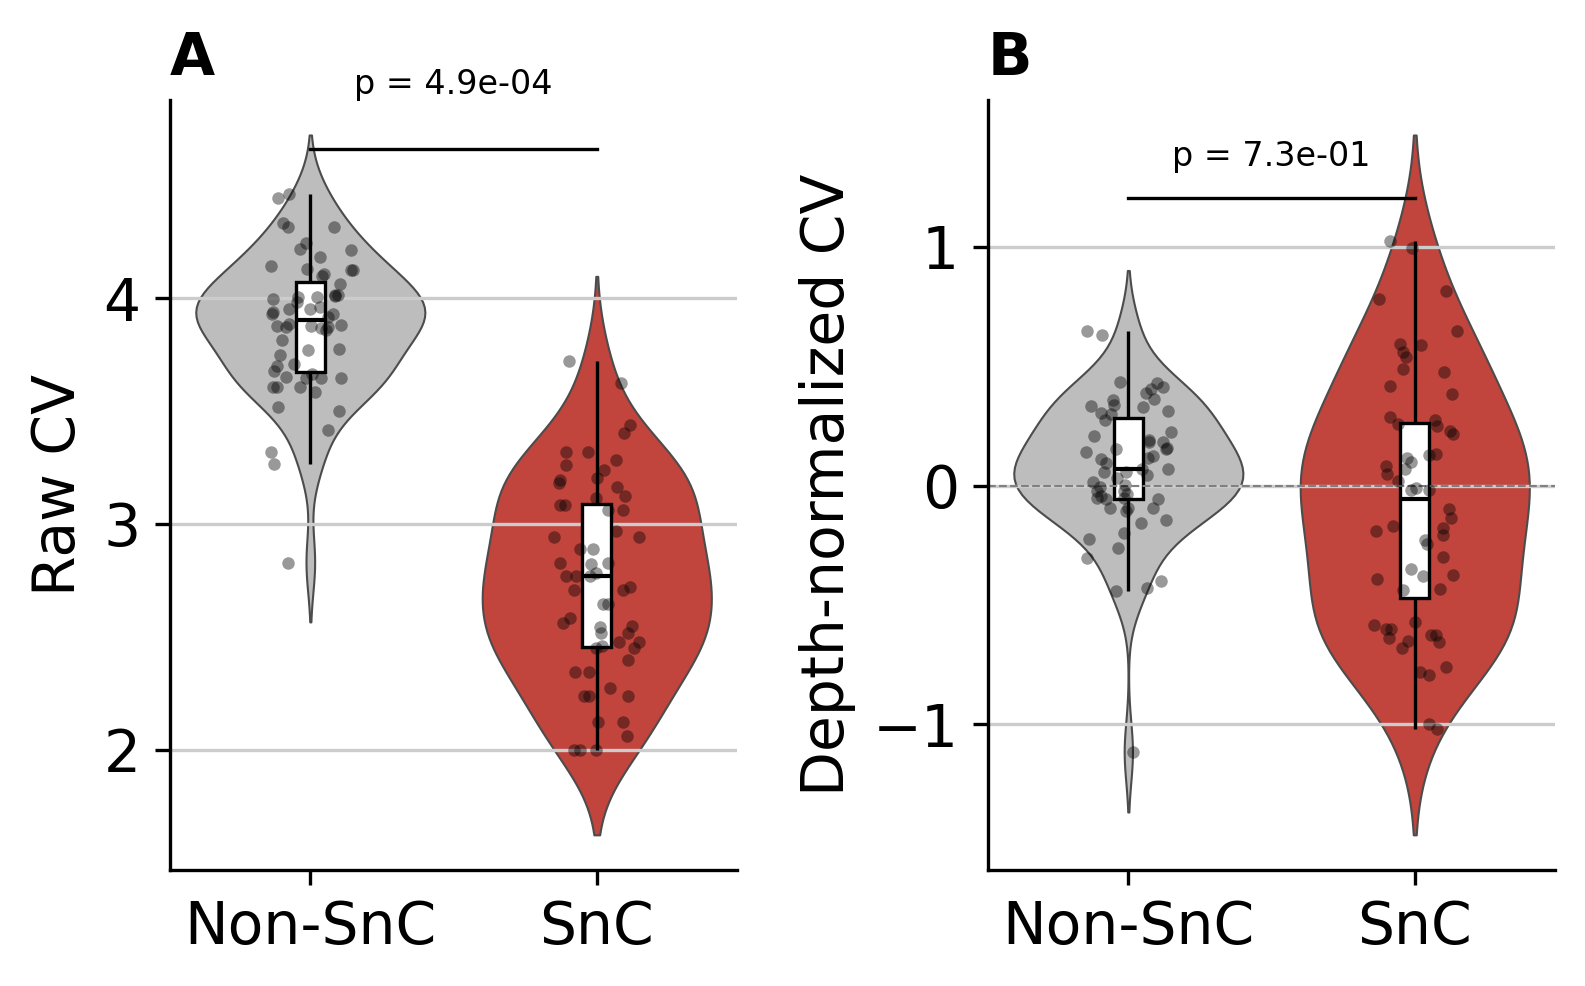

✓ Saved: psychad_aging_microglia_cv_raw_vs_normalized.pdf


In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-8: DEPTH-NORMALIZED CV BOXPLOT
# ════════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(5.5, 3.5))

# ────────────────────────────────────────────────────────────────────────────────
# Panel A: Raw CV
# ────────────────────────────────────────────────────────────────────────────────
ax = axes[0]

sns.violinplot(data=paired_data, x="Senescence", y="median_cv",
               order=["Non-SnC", "SnC"], hue="Senescence", hue_order=["Non-SnC", "SnC"],
               palette=SNC_COLORS, inner=None, linewidth=0.5, legend=False, ax=ax)

sns.stripplot(data=paired_data, x="Senescence", y="median_cv",
              order=["Non-SnC", "SnC"], color="black", size=3, alpha=0.4,
              jitter=0.15, ax=ax)

sns.boxplot(data=paired_data, x="Senescence", y="median_cv",
            order=["Non-SnC", "SnC"], width=0.1, showcaps=False,
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=0.8),
            whiskerprops=dict(color="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1),
            fliersize=0, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Raw CV")
ax.set_title("A", loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ymax = paired_data["median_cv"].max() * 1.1
ax.text(0.5, ymax, f"p = {pval_raw:.1e}", ha="center", fontsize=8)
ax.plot([0, 1], [ymax * 0.95, ymax * 0.95], "k-", linewidth=0.8)

# ────────────────────────────────────────────────────────────────────────────────
# Panel B: Depth-normalized CV (residuals)
# ────────────────────────────────────────────────────────────────────────────────
ax = axes[1]

sns.violinplot(data=paired_data, x="Senescence", y="cv_residual",
               order=["Non-SnC", "SnC"], hue="Senescence", hue_order=["Non-SnC", "SnC"],
               palette=SNC_COLORS, inner=None, linewidth=0.5, legend=False, ax=ax)

sns.stripplot(data=paired_data, x="Senescence", y="cv_residual",
              order=["Non-SnC", "SnC"], color="black", size=3, alpha=0.4,
              jitter=0.15, ax=ax)

sns.boxplot(data=paired_data, x="Senescence", y="cv_residual",
            order=["Non-SnC", "SnC"], width=0.1, showcaps=False,
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=0.8),
            whiskerprops=dict(color="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1),
            fliersize=0, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Depth-normalized CV")
ax.set_title("B", loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)

ymax = paired_data["cv_residual"].abs().max() * 1.2
ax.text(0.5, ymax, f"p = {pval_resid:.1e}", ha="center", fontsize=8)
ax.plot([0, 1], [ymax * 0.9, ymax * 0.9], "k-", linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_cv_raw_vs_normalized.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Saved: {DATASET}_{CELL_TYPE.lower()}_cv_raw_vs_normalized.pdf")

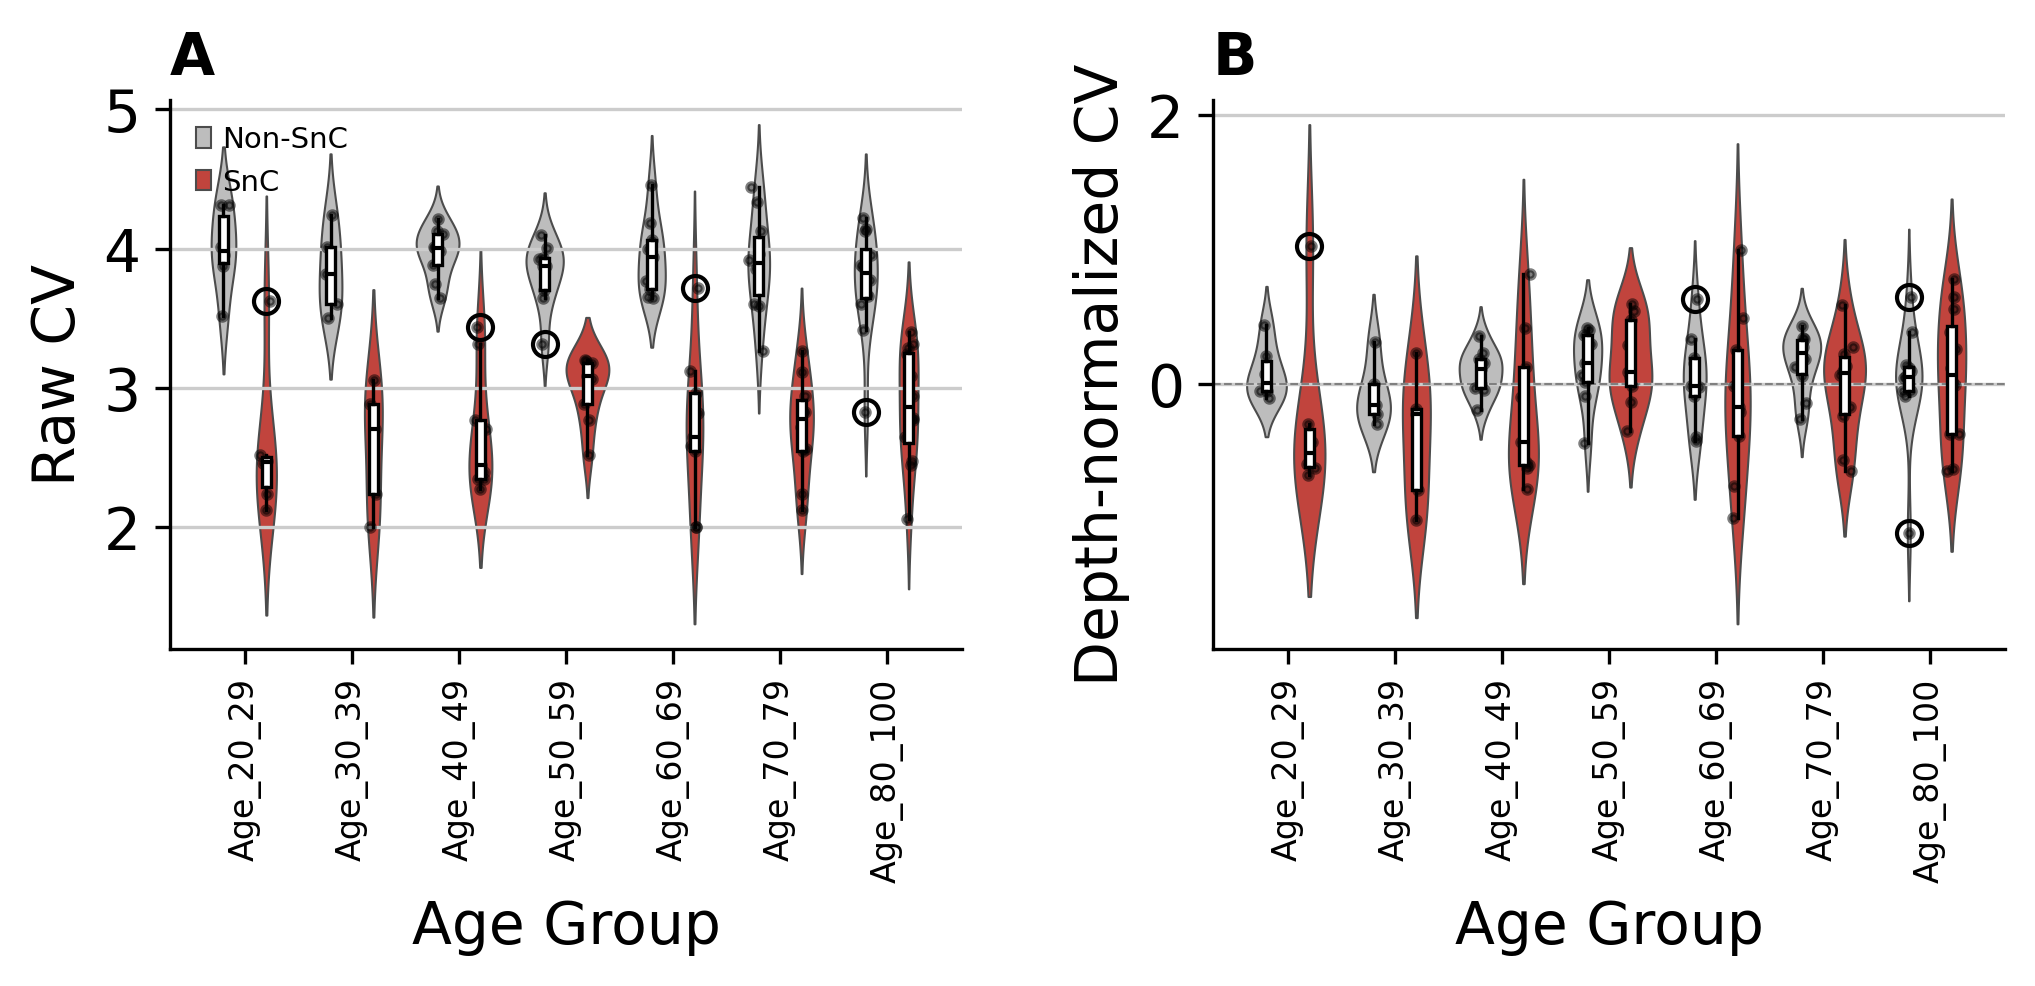

✓ Saved: psychad_aging_microglia_cv_by_studygroup.pdf


In [19]:
# ════════════════════════════════════════════════════════════════════════════════
# 08B-9: CV BY STUDY GROUP PLOT (Boxplot centered in violin)
# ════════════════════════════════════════════════════════════════════════════════

study_groups = [g for g in GROUP_ORDER if g in paired_data["Study_Group"].values]
n_groups = len(study_groups)

fig, axes = plt.subplots(1, 2, figsize=(max(6, n_groups * 1.0), 3.5))

# Dodge width for positioning
dodge_width = 0.4

# ────────────────────────────────────────────────────────────────────────────────
# Panel A: Raw CV
# ────────────────────────────────────────────────────────────────────────────────
ax = axes[0]

sns.violinplot(data=paired_data, x="Study_Group", y="median_cv",
               hue="Senescence", hue_order=["Non-SnC", "SnC"],
               order=study_groups, palette=SNC_COLORS,
               inner=None, linewidth=0.5, dodge=True, ax=ax)

# Manually add stripplot and boxplot at correct positions
for i, sg in enumerate(study_groups):
    for j, snc in enumerate(["Non-SnC", "SnC"]):
        subset = paired_data[(paired_data["Study_Group"] == sg) & 
                             (paired_data["Senescence"] == snc)]["median_cv"].dropna()
        if len(subset) == 0:
            continue
        
        pos = i + (j - 0.5) * dodge_width
        
        # Jittered points
        jitter = np.random.normal(0, 0.03, len(subset))
        ax.scatter(pos + jitter, subset, color="black", s=4, alpha=0.5, zorder=3)
        
        # Boxplot
        bp = ax.boxplot(subset, positions=[pos], widths=0.08, showcaps=False, 
                        patch_artist=True, zorder=4)
        bp['boxes'][0].set(facecolor='white', edgecolor='black', linewidth=0.8)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=0.8)
        bp['medians'][0].set(color='black', linewidth=1)

ax.set_xlabel("Age Group" if STUDY_TYPE == "aging" else "Study Group")
ax.set_ylabel("Raw CV")
ax.set_title("A", loc="left", fontweight="bold")
ax.set_xticks(range(n_groups))
ax.set_xticklabels(study_groups, rotation=90, ha="center", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], loc="upper left", frameon=False, fontsize=7)

# ────────────────────────────────────────────────────────────────────────────────
# Panel B: Depth-normalized CV
# ────────────────────────────────────────────────────────────────────────────────
ax = axes[1]

sns.violinplot(data=paired_data, x="Study_Group", y="cv_residual",
               hue="Senescence", hue_order=["Non-SnC", "SnC"],
               order=study_groups, palette=SNC_COLORS,
               inner=None, linewidth=0.5, dodge=True, ax=ax)

# Manually add stripplot and boxplot at correct positions
for i, sg in enumerate(study_groups):
    for j, snc in enumerate(["Non-SnC", "SnC"]):
        subset = paired_data[(paired_data["Study_Group"] == sg) & 
                             (paired_data["Senescence"] == snc)]["cv_residual"].dropna()
        if len(subset) == 0:
            continue
        
        pos = i + (j - 0.5) * dodge_width
        
        # Jittered points
        jitter = np.random.normal(0, 0.03, len(subset))
        ax.scatter(pos + jitter, subset, color="black", s=4, alpha=0.5, zorder=3)
        
        # Boxplot
        bp = ax.boxplot(subset, positions=[pos], widths=0.08, showcaps=False, 
                        patch_artist=True, zorder=4)
        bp['boxes'][0].set(facecolor='white', edgecolor='black', linewidth=0.8)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=0.8)
        bp['medians'][0].set(color='black', linewidth=1)

ax.set_xlabel("Age Group" if STUDY_TYPE == "aging" else "Study Group")
ax.set_ylabel("Depth-normalized CV")
ax.set_title("B", loc="left", fontweight="bold")
ax.set_xticks(range(n_groups))
ax.set_xticklabels(study_groups, rotation=90, ha="center", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.legend([], [], frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_cv_by_studygroup.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Saved: {DATASET}_{CELL_TYPE.lower()}_cv_by_studygroup.pdf")

---

## 08C: Variance Partitioning Analysis

**Question**: What factors explain variance in gene expression, and how does senescence compare to donor, age, and sex effects?

**Method**: Linear mixed models via `variancePartition` (R) decompose variance into Donor, Senescence, Study_Group, Sex, and Residual components.

**Note**: This analysis uses R for the `variancePartition` package — run the generated R script after preparing data in Python.

---

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 08C: VARIANCE PARTITIONING ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
# Question: What factors explain variance in gene expression?
# Method: variancePartition on pseudobulk (donor × senescence)
# ════════════════════════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────────────────────
# 08C-1: LIBRARIES
# ────────────────────────────────────────────────────────────────────────────────

suppressPackageStartupMessages({
  library(variancePartition)
  library(edgeR)
  library(ggplot2)
  library(dplyr)
  library(Seurat)
  library(qs)
})

cat("✓ Libraries loaded\n")

Warning message:
“package ‘variancePartition’ was built under R version 4.3.2”
Warning message:
“package ‘limma’ was built under R version 4.3.3”
Warning message:
“package ‘BiocParallel’ was built under R version 4.3.3”
Warning message:
“package ‘edgeR’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘qs’ was built under R version 4.3.3”


✓ Libraries loaded


In [2]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-2: CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────

DATASET <- "psychad_aging"
CELL_TYPE <- "Microglia"

STUDY_CONFIG <- list(
  psychad_aging = list(
    type = "aging",
    cell_type_col = "subclass",
    sample_col = "Sample",
    senescence_col = "senescence_label",
    covariates = list(
      Donor = "Sample",
      Senescence = "senescence_label",
      Study_Group = "Study_Group",
      Sex = "Sex"
      # Cohort = "Cohort"
    ),
    group_order = c("Age_20_29", "Age_30_39", "Age_40_49", "Age_50_59",
                    "Age_60_69", "Age_70_79", "Age_80_100")
  ),
  psychad_ad = list(
    type = "disease",
    cell_type_col = "subclass",
    sample_col = "Sample",
    senescence_col = "senescence_label",
    covariates = list(
      Donor = "Sample",
      Senescence = "senescence_label",
      Study_Group = "Study_Group",
      Sex = "Sex"
    ),
    group_order = c("Control", "MCI", "AD")
  ),
  psychencode = list(
    type = "aging",
    cell_type_col = "cell_type",
    sample_col = "sample_id",
    senescence_col = "senescence_label",
    covariates = list(
      Donor = "sample_id",
      Senescence = "senescence_label",
      Study_Group = "Study_Group",
      Sex = "Biological_Sex"
    ),
    group_order = c("Age_20_29", "Age_30_39", "Age_40_49", "Age_50_59",
                    "Age_60_69", "Age_70_79", "Age_80_100")
  )
)

# Extract config
config <- STUDY_CONFIG[[DATASET]]
CELL_TYPE_COL <- config$cell_type_col
SAMPLE_COL <- config$sample_col
SENESCENCE_COL <- config$senescence_col
COVARIATES <- config$covariates

# Paths
BASE_DIR <- "/fs/scratch/PAS2598/senescence_analysis"
SC_FILE <- file.path(BASE_DIR, "data", "04_subclustered", DATASET, paste0(DATASET, "_subclustered.qs"))
RESULTS_DIR <- file.path(BASE_DIR, "results", "08_variability", DATASET, tolower(CELL_TYPE))
FIGURES_DIR <- file.path(BASE_DIR, "figures", "08_variability", DATASET, tolower(CELL_TYPE))

dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURES_DIR, recursive = TRUE, showWarnings = FALSE)

# Colors
VP_COLORS <- c(
  "Donor" = "#4E79A7",
  "Senescence" = "#D73027",
  "Study_Group" = "#59A14F",
  "Sex" = "#F28E2B",
  "Cohort" = "#B07AA1",
  "Residuals" = "#BDBDBD"
)

cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Dataset:", DATASET, "\n")
cat("Cell type:", CELL_TYPE, "\n")
cat("Covariates:", paste(names(COVARIATES), collapse = ", "), "\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

════════════════════════════════════════════════════════════════════════════════
Dataset: psychad_aging 
Cell type: Microglia 
Covariates: Donor, Senescence, Study_Group, Sex 
════════════════════════════════════════════════════════════════════════════════


In [3]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-3: LOAD DATA
# ────────────────────────────────────────────────────────────────────────────────

cat("\nLoading data...\n")

seurat_all <- qread(SC_FILE)
cat("  Total cells:", ncol(seurat_all), "\n")

seurat <- subset(seurat_all, subset = !!sym(CELL_TYPE_COL) == CELL_TYPE)
cat(" ", CELL_TYPE, "cells:", ncol(seurat), "\n")

cat("\nSenescence distribution:\n")
print(table(seurat@meta.data[[SENESCENCE_COL]]))

rm(seurat_all)
gc()

cat("\n✓ Data loaded\n")


Loading data...
  Total cells: 122192 
  Microglia cells: 22475 

Senescence distribution:

Non-SnC     SnC 
  20242    2233 


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4527973,241.9,7922440,423.2,7922440,423.2
Vcells,942720781,7192.4,7463533335,56942.3,7153359426,54575.9



✓ Data loaded


In [4]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-4: CREATE PSEUDOBULK
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Creating pseudobulk...\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

counts <- GetAssayData(seurat, layer = "counts")

seurat$donor_snc <- paste0(seurat@meta.data[[SAMPLE_COL]], "-", 
                           seurat@meta.data[[SENESCENCE_COL]])

donor_snc_ids <- unique(seurat$donor_snc)
cat("  Aggregating", length(donor_snc_ids), "samples...\n")

pseudobulk <- sapply(donor_snc_ids, function(id) {
  cells <- which(seurat$donor_snc == id)
  if (length(cells) > 1) {
    Matrix::rowSums(counts[, cells])
  } else {
    counts[, cells]
  }
})
colnames(pseudobulk) <- donor_snc_ids

cat("  Pseudobulk:", nrow(pseudobulk), "genes x", ncol(pseudobulk), "samples\n")


════════════════════════════════════════════════════════════════════════════════
Creating pseudobulk...
════════════════════════════════════════════════════════════════════════════════
  Aggregating 227 samples...
  Pseudobulk: 34890 genes x 227 samples


In [5]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-5: CREATE METADATA
# ────────────────────────────────────────────────────────────────────────────────

cat("\nCreating metadata...\n")

# Build summarise expressions dynamically
summarise_exprs <- lapply(names(COVARIATES), function(out_name) {
  src_col <- COVARIATES[[out_name]]
  rlang::expr(first(.data[[!!src_col]]))
})
names(summarise_exprs) <- names(COVARIATES)
summarise_exprs$n_cells <- rlang::expr(n())

meta <- seurat@meta.data %>%
  mutate(donor_snc = paste0(.data[[SAMPLE_COL]], "-", .data[[SENESCENCE_COL]])) %>%
  group_by(donor_snc) %>%
  summarise(!!!summarise_exprs, .groups = "drop") %>%
  as.data.frame()

rownames(meta) <- meta$donor_snc

cat("  Samples:", nrow(meta), "\n")

# Check NAs
na_check <- sapply(meta[, names(COVARIATES), drop = FALSE], function(x) sum(is.na(x)))
if (any(na_check > 0)) {
  cat("  ⚠ NAs found:", paste(names(na_check)[na_check > 0], na_check[na_check > 0], sep = "=", collapse = ", "), "\n")
} else {
  cat("  ✓ No missing values\n")
}


Creating metadata...
  Samples: 227 
  ✓ No missing values


In [6]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-6: FILTER AND NORMALIZE
# ────────────────────────────────────────────────────────────────────────────────

cat("\nFiltering and normalizing...\n")

common_samples <- intersect(colnames(pseudobulk), rownames(meta))
pseudobulk <- pseudobulk[, common_samples]
meta <- meta[common_samples, ]

cat("  Aligned samples:", length(common_samples), "\n")

dge <- DGEList(counts = pseudobulk)
keep <- filterByExpr(dge, min.count = 10, min.total.count = 15)
dge <- dge[keep, ]
cat("  Genes after filtering:", nrow(dge), "\n")

dge <- calcNormFactors(dge, method = "TMM")
logCPM <- cpm(dge, log = TRUE, prior.count = 1)

cat("  Final:", nrow(logCPM), "genes x", ncol(logCPM), "samples\n")

# Verify alignment
stopifnot(all(colnames(logCPM) == rownames(meta)))
cat("  ✓ Alignment verified\n")


Filtering and normalizing...
  Aligned samples: 227 


Warning message in filterByExpr.DGEList(dge, min.count = 10, min.total.count = 15):
“All samples appear to belong to the same group.”


  Genes after filtering: 3898 
  Final: 3898 genes x 227 samples
  ✓ Alignment verified


In [7]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-7: RUN VARIANCE PARTITIONING
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Running variance partitioning...\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

# Convert to factors
for (cov in names(COVARIATES)) {
  meta[[cov]] <- as.factor(meta[[cov]])
}

cat("\nFactor levels:\n")
for (cov in names(COVARIATES)) {
  n_lev <- nlevels(meta[[cov]])
  if (n_lev <= 5) {
    cat("  ", cov, ": ", paste(levels(meta[[cov]]), collapse = ", "), "\n", sep = "")
  } else {
    cat("  ", cov, ": ", n_lev, " levels\n", sep = "")
  }
}

# Build formula
form_str <- paste0("~ ", paste0("(1|", names(COVARIATES), ")", collapse = " + "))
form <- as.formula(form_str)

cat("\nFormula:", form_str, "\n")
cat("Genes:", nrow(logCPM), "\n")
cat("Samples:", ncol(logCPM), "\n")
cat("\nRunning... (this may take several minutes)\n")

varPart <- fitExtractVarPartModel(logCPM, form, meta)

cat("\n✓ Variance partitioning complete\n")


════════════════════════════════════════════════════════════════════════════════
Running variance partitioning...
════════════════════════════════════════════════════════════════════════════════

Factor levels:
  Donor: 124 levels
  Senescence: Non-SnC, SnC
  Study_Group: 7 levels
  Sex: Female, Male

Formula: ~ (1|Donor) + (1|Senescence) + (1|Study_Group) + (1|Sex) 
Genes: 3898 
Samples: 227 

Running... (this may take several minutes)

✓ Variance partitioning complete


In [8]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-8: RESULTS
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Results\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

varPart_summary <- data.frame(
  Factor = colnames(varPart),
  Mean_pct = round(colMeans(varPart) * 100, 2),
  Median_pct = round(apply(varPart, 2, median) * 100, 2),
  SD_pct = round(apply(varPart, 2, sd) * 100, 2)
)
varPart_summary <- varPart_summary[order(-varPart_summary$Mean_pct), ]

print(varPart_summary, row.names = FALSE)


════════════════════════════════════════════════════════════════════════════════
Results
════════════════════════════════════════════════════════════════════════════════
      Factor Mean_pct Median_pct SD_pct
   Residuals    80.18      83.98  16.39
       Donor    15.44      11.61  15.52
  Senescence     2.22       1.77   2.09
 Study_Group     1.28       0.00   2.64
         Sex     0.88       0.00   1.70


In [9]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-9: VISUALIZATION
# ────────────────────────────────────────────────────────────────────────────────

cat("\nCreating figures...\n")

# Violin plot
pdf(file.path(FIGURES_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_violin.pdf")),
    width = 6, height = 4)
plotVarPart(varPart, col = VP_COLORS[colnames(varPart)])
dev.off()
cat("  ✓ varpart_violin.pdf\n")

# Bar plot
p <- ggplot(varPart_summary, aes(x = reorder(Factor, -Mean_pct), y = Mean_pct, fill = Factor)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_errorbar(aes(ymin = Mean_pct - SD_pct, ymax = Mean_pct + SD_pct), width = 0.2) +
  scale_fill_manual(values = VP_COLORS) +
  labs(x = NULL, y = "Variance Explained (%)") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_bar.pdf")),
       p, width = 5, height = 4)
cat("  ✓ varpart_bar.pdf\n")


Creating figures...


agg_record_651436069 
                   2

  ✓ varpart_violin.pdf
  ✓ varpart_bar.pdf


In [10]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-10: SAVE
# ────────────────────────────────────────────────────────────────────────────────

cat("\nSaving results...\n")

write.csv(as.data.frame(varPart), 
          file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_full.csv")))
write.csv(varPart_summary, 
          file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_summary.csv")),
          row.names = FALSE)

cat("  ✓ varpart_full.csv\n")
cat("  ✓ varpart_summary.csv\n")

# ────────────────────────────────────────────────────────────────────────────────
# 08C-11: SUMMARY
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("08C Complete\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("\nVariance explained:\n")
for (i in 1:nrow(varPart_summary)) {
  cat("  ", varPart_summary$Factor[i], ": ", varPart_summary$Mean_pct[i], "%\n", sep = "")
}


Saving results...
  ✓ varpart_full.csv
  ✓ varpart_summary.csv

════════════════════════════════════════════════════════════════════════════════
08C Complete
════════════════════════════════════════════════════════════════════════════════

Variance explained:
  Residuals: 80.18%
  Donor: 15.44%
  Senescence: 2.22%
  Study_Group: 1.28%
  Sex: 0.88%
